In [1]:
import pickle
from glob import glob
import os
import yaml
from easydict import EasyDict as edict
import pandas as pd
import networkx as nx
import collections
import numpy as np
from scipy.signal import convolve2d
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42

import torch
import torch.nn as nn
from model import *
from utils.train_helper import load_model
from torch.utils.tensorboard.writer import SummaryWriter

### MLP OuterNet

In [2]:
exp='pretrain'

./exp/pretrain/XorNeuronMLP_001_mnist_2025-Dec-24-23-16-54
Loaded model from /home/yc/repo/xor_neuron_yoon/exp/pretrain/XorNeuronMLP_001_mnist_2025-Dec-24-23-16-54/model_snapshot_best_pretrained0.pth to cuda
Loaded model from /home/yc/repo/xor_neuron_yoon/exp/pretrain/XorNeuronMLP_001_mnist_2025-Dec-24-23-16-54/model_snapshot_best_phase1.pth to cuda


/home/yc/repo/xor_neuron_yoon/utils/train_helper.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_snapshot = torch.load(file_name, map_location=device)


./exp/pretrain/XorNeuronMLP_001_mnist_2025-Dec-24-23-19-00
Loaded model from /home/yc/repo/xor_neuron_yoon/exp/pretrain/XorNeuronMLP_001_mnist_2025-Dec-24-23-19-00/model_snapshot_best_pretrained0.pth to cuda
Loaded model from /home/yc/repo/xor_neuron_yoon/exp/pretrain/XorNeuronMLP_001_mnist_2025-Dec-24-23-19-00/model_snapshot_best_phase1.pth to cuda


/home/yc/repo/xor_neuron_yoon/utils/train_helper.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_snapshot = torch.load(file_name, map_location=device)


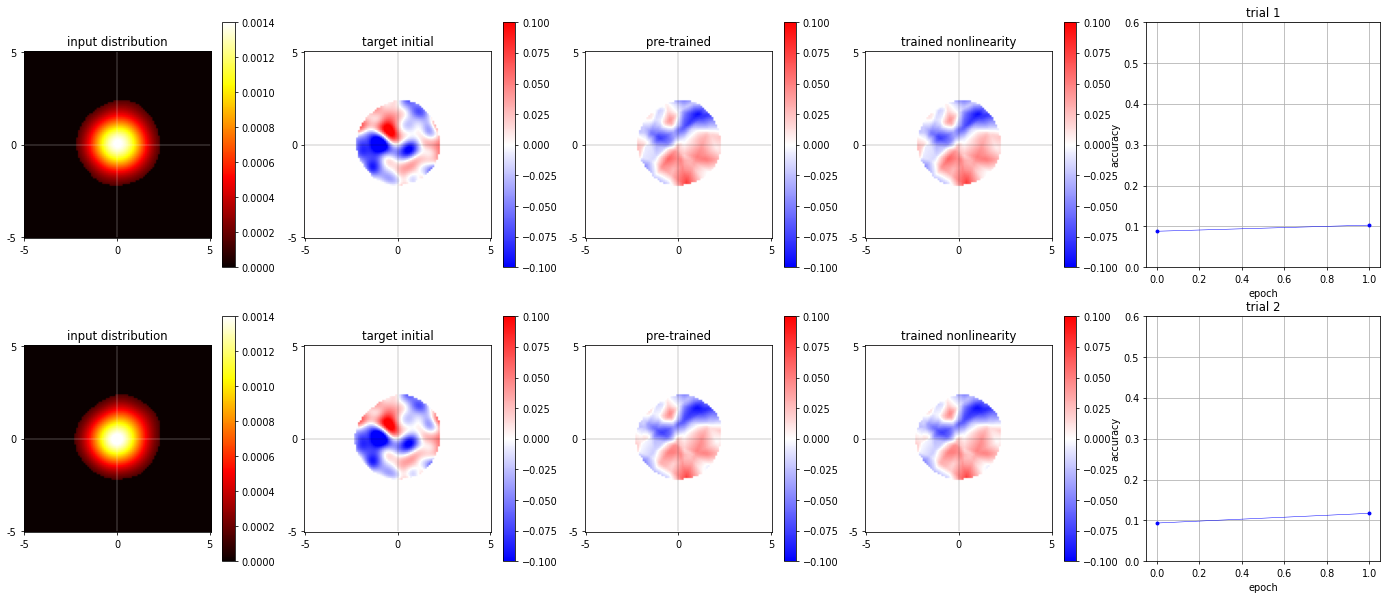

In [16]:
# dirs = glob('../xor_neuron_exp/xor_neuron_mlp_cifar/XorNeuron*')
from dataset.innernet_data import InnerNetData


dirs = glob(f'./exp/{exp}/Xor*')
dirs.sort(key=os.path.abspath)
f, axes = plt.subplots(nrows=len(dirs), ncols=5, figsize=(25, 5*len(dirs)), dpi=70,squeeze=False)

for ii, dr in enumerate(dirs):
    print(dr)
    phase1_file = glob(dr + '/*phase1.p')[0]
    phase2_file = glob(dr + '/*phase2.p')[0]
    phase1_data = pickle.load(open(phase1_file, 'rb'))
    phase2_data = pickle.load(open(phase2_file, 'rb'))
    # phase1_data=torch.load(phase1_file, map_location='cpu')
    # phase2_data=torch.load(phase2_file, map_location='cpu')
    config_file = glob(dr + '/*.yaml')[0]
    config = edict(yaml.load(open(config_file, 'r'), Loader=yaml.FullLoader))
    # config.save_dir = '../exp' + config.save_dir[25:]
    
#     config['exp_dir'] = dr
#     config['dataset']['data_path'] = '../xor_neuron_data/data'
#     config['test']['test_model'] = dr + '/model_snapshot_best_phase2.pth'
#     config['test']['batch_size'] = 100
#     cfg_path = dr + '/config_test.yaml'
#     with open(cfg_path, 'w') as ymlfile:
#         yaml.dump(config, ymlfile, explicit_start=True)
#     ! python3 run_exp_local.py -c {cfg_path} -t
    
    # ========== Column 5: Model Accuracy ==============

    axes[ii,4].plot(np.hstack([phase1_data['val_acc'], phase2_data['val_acc']]), 'b.-', lw=0.5)
    axes[ii,4].set_xlabel('epoch')
    axes[ii,4].set_ylabel('accuracy')
#     axes[ii,4].set_ylim([0.8,1]) # MNIST
    axes[ii,4].set_ylim([0,0.6]) # CIFAR10
    axes[ii,4].set_title(f'trial {1+ii}')
    axes[ii,4].grid(True)

    # create models
    model_pretrain = InnerNet(config)
    model_phase1 = InnerNet(config)
    
    # load test model
    load_model(model_pretrain.inner_net, config.save_dir + config.pretrain.best_model[0])
    load_model(model_phase1.inner_net, config.save_dir + config.train.best_model)

    nb = 101
    x = np.linspace(-5, 5, nb)
    y = np.linspace(-5, 5, nb)
    xv, yv = np.meshgrid(x, y)
    xy = np.vstack([xv.reshape(-1), yv.reshape(-1)]).T
    mvn = multivariate_normal(mean=[0, 0], cov=[[1/9, 0], [0, 1/9]])
    gaussian_kernel = mvn.pdf(xy).reshape(nb, nb)
    gaussian_kernel /= gaussian_kernel.sum()
    # seed = int(str(config.seed) + '00' + str(1+ii))
    seed=int(str(config.seed))
   
    npr = np.random.RandomState(seed=seed)
    init_unif = npr.uniform(-1, 1, size=(nb, nb))
    targets = convolve2d(init_unif, gaussian_kernel, mode='same').reshape(-1,1)

    # # ------------new--
    # dataset = InnerNetData(config, split='train')
    # # 这里的 targets 就是模型训练时真正看到的那个目标
    # targets = dataset.targets.reshape(101, 101) 
    # xy = dataset.xy # 确保输入坐标点也是完全一致的
    # # --------------

    model_pretrain.eval()
    model_phase1.eval()

    out_pretrain = model_pretrain.inner_net(torch.Tensor(xy).cuda())
    out_phase1 = model_phase1.inner_net(torch.Tensor(xy).cuda())

    # ========== Column 1: Input distribution ==============
#     input2innerAll = glob(dr+'/*001*/input2innerAll.p')[0]
#     input2innerAll = pickle.load(open(input2innerAll, 'rb'))
    input2innerAll = glob(dr+'/input2innerAll.p')[0]
    input2innerAll = pickle.load(open(input2innerAll, 'rb'))
    input2innerAll = [input2innerAll[k] for k in range(len(input2innerAll))]
    input2innerAll = np.array(input2innerAll)
    input2innerAll = np.moveaxis(input2innerAll, -1, 0)
    input2innerAll = input2innerAll.reshape((config.model.arg_in_dim, -1))
    
    xedges = yedges = np.arange(-5.05,5.1,0.1)
    pdf, _, _ = np.histogram2d(input2innerAll[0], input2innerAll[1], bins=(xedges, yedges))
    pdf = convolve2d(pdf, gaussian_kernel, mode='same')
    pdf /= sum(pdf.flatten())
    
    threshold = 0.0005
    while True:
        row, col = np.where(pdf > threshold)
        if sum(pdf[row, col]) > 0.9:
            break
        else:
            threshold -= 0.00001

    mask = np.zeros((101, 101))
    mask[row, col] = 1
    
    cmax = max(pdf.flatten()).round(4)
    im = axes[ii,0].imshow(mask * pdf, cmap='hot', vmin=0, vmax=cmax)
    axes[ii,0].set_title('input distribution')
    axes[ii,0].set_xticks([0, 50, 100])
    axes[ii,0].set_xticklabels(['-5', '0', '5'])
    axes[ii,0].set_yticks([0, 50, 100])
    axes[ii,0].set_yticklabels(['5', '0', '-5'])
    axes[ii,0].plot([0,100], [50,50], 'w', lw=0.3)
    axes[ii,0].plot([50,50], [0,100], 'w', lw=0.3)
    f.colorbar(im, ax=axes[ii,0])
    # ========== Column 2: Target Initial ==============
    cmax = max(abs(np.min(targets)), abs(np.max(targets))).round()
    im = axes[ii,1].imshow(mask * targets.reshape(101, 101), cmap='bwr', vmin=-cmax, vmax=cmax)
    axes[ii,1].set_title('target initial')
    axes[ii,1].set_xticks([0, 50, 100])
    axes[ii,1].set_xticklabels(['-5', '0', '5'])
    axes[ii,1].set_yticks([0, 50, 100])
    axes[ii,1].set_yticklabels(['5', '0', '-5'])
    axes[ii,1].plot([0,100], [50,50], 'k', lw=0.2)
    axes[ii,1].plot([50,50], [0,100], 'k', lw=0.2)
    f.colorbar(im, ax=axes[ii,1])

    

    # ========== Column 3: Pre-trained  ==============
    cmax = max(abs(min(out_pretrain)), abs(max(out_pretrain))).round().data.cpu().numpy()[0]
    im = axes[ii,2].imshow(mask * out_pretrain.data.cpu().numpy().reshape(101, 101), cmap='bwr', vmin=-cmax, vmax=cmax)
    axes[ii,2].set_title('pre-trained')
    axes[ii,2].set_xticks([0, 50, 100])
    axes[ii,2].set_xticklabels(['-5', '0', '5'])
    axes[ii,2].set_yticks([0, 50, 100])
    axes[ii,2].set_yticklabels(['5', '0', '-5'])
    axes[ii,2].plot([0,100], [50,50], 'k', lw=0.2)
    axes[ii,2].plot([50,50], [0,100], 'k', lw=0.2)
    f.colorbar(im, ax=axes[ii,2])
    # ========== Column 4: Trained nonlinearity ==============
    cmax = max(abs(min(out_phase1)), abs(max(out_phase1))).round().data.cpu().numpy()[0]
    im = axes[ii,3].imshow(mask * out_phase1.data.cpu().numpy().reshape(101, 101), cmap='bwr', vmin=-cmax, vmax=cmax)
    axes[ii,3].set_title('trained nonlinearity')
    axes[ii,3].set_xticks([0, 50, 100])
    axes[ii,3].set_xticklabels(['-5', '0', '5'])
    axes[ii,3].set_yticks([0, 50, 100])
    axes[ii,3].set_yticklabels(['5', '0', '-5'])
    axes[ii,3].plot([0,100], [50,50], 'k', lw=0.2)
    axes[ii,3].plot([50,50], [0,100], 'k', lw=0.2)
    f.colorbar(im, ax=axes[ii,3])

    # # check pretrain
    # residual = targets.reshape(101, 101) - out_pretrain.data.cpu().numpy().reshape(101, 101)
    # axes[ii,3].imshow(mask * residual, cmap='bwr')
    # f.colorbar(im, ax=axes[ii,3])

plt.show()

### Conv OuterNet

In [ ]:
dirs = glob('../xor_neuron_exp/xor_neuron_conv_mnist/XorNeuron*')
dirs.sort(key=os.path.abspath)
f, axes = plt.subplots(nrows=len(dirs), ncols=5, figsize=(25, 5*len(dirs)), dpi=70)

for ii, dr in enumerate(dirs):
    phase1_file = glob(dr + '/*phase1.p')[0]
    phase2_file = glob(dr + '/*phase2.p')[0]
    phase1_data = pickle.load(open(phase1_file, 'rb'))
    phase2_data = pickle.load(open(phase2_file, 'rb'))
    config_file = glob(dr + '/*.yaml')[0]
    config = edict(yaml.load(open(config_file, 'r'), Loader=yaml.FullLoader))
    config.save_dir = '../xor_neuron_exp' + config.save_dir[25:]
    
#     config['exp_dir'] = dr
#     config['dataset']['data_path'] = '../xor_neuron_data/data'
#     config['test']['test_model'] = dr + '/model_snapshot_best_phase2.pth'
#     config['test']['batch_size'] = 100
#     cfg_path = dr + '/config_test.yaml'
#     with open(cfg_path, 'w') as ymlfile:
#         yaml.dump(config, ymlfile, explicit_start=True)
#     ! python3 run_exp_local.py -c {cfg_path} -t
    
    # ========== Column 5: Model Accuracy ==============
    axes[ii,4].plot(np.hstack([phase1_data['val_acc'], phase2_data['val_acc']]), 'b.-', lw=0.5)
    axes[ii,4].set_xlabel('epoch')
    axes[ii,4].set_ylabel('accuracy')
    axes[ii,4].set_ylim([0.9,1]) # MNIST
#     axes[ii,4].set_ylim([0.5,0.8]) # CIFAR10
    axes[ii,4].set_title(f'trial {1+ii}')
    axes[ii,4].grid(True)
    
    # create models
    model_pretrain = InnerNet(config)
    model_phase1 = InnerNet(config)

    # load test model
    load_model(model_pretrain.inner_net, config.save_dir + config.pretrain.best_model)
    load_model(model_phase1.inner_net, config.save_dir + config.train.best_model)

    nb = 101
    x = np.linspace(-5, 5, nb)
    y = np.linspace(-5, 5, nb)
    xv, yv = np.meshgrid(x, y)
    xy = np.vstack([xv.reshape(-1), yv.reshape(-1)]).T
    mvn = multivariate_normal(mean=[0, 0], cov=[[1/9, 0], [0, 1/9]])
    gaussian_kernel = mvn.pdf(xy).reshape(nb, nb)
    gaussian_kernel /= gaussian_kernel.sum()
    seed = int(str(config.seed))
    npr = np.random.RandomState(seed=seed)
    init_unif = npr.uniform(-1, 1, size=(nb, nb))
    targets = convolve2d(init_unif, gaussian_kernel, mode='same').reshape(-1,1)

    model_pretrain.eval()
    model_phase1.eval()

    sqrt_batch_size = np.int(np.sqrt(xy.shape[0]))
    assert sqrt_batch_size ** 2 == xy.shape[0]

    out = xy.T.reshape(1, config.model.arg_in_dim, sqrt_batch_size, sqrt_batch_size)
    out_pretrain = model_pretrain.inner_net(torch.Tensor(out))
    out_pretrain = out_pretrain.reshape(-1,1)

    out = xy.T.reshape(1, config.model.arg_in_dim, sqrt_batch_size, sqrt_batch_size)
    out_phase1 = model_phase1.inner_net(torch.Tensor(out))
    out_phase1 = out_phase1.reshape(-1,1)

    # ========== Column 1: Input distribution ==============
#     input2innerAll = glob(dr+'/*001*/input2innerAll.p')[0]
#     input2innerAll = pickle.load(open(input2innerAll, 'rb'))
    input2innerAll = glob(dr+'/input2innerAll.p')[0]
    input2innerAll = pickle.load(open(input2innerAll, 'rb'))
    temp = input2innerAll[0]
    for k in range(1, len(input2innerAll)):
        temp = np.vstack([temp, input2innerAll[k]])
    input2innerAll = temp.T
    
    xedges = yedges = np.arange(-5.05,5.1,0.1)
    pdf, _, _ = np.histogram2d(input2innerAll[0], input2innerAll[1], bins=(xedges, yedges))
    pdf = convolve2d(pdf, gaussian_kernel, mode='same')
    pdf /= sum(pdf.flatten())
    
    threshold = 0.0005
    while True:
        row, col = np.where(pdf > threshold)
        if sum(pdf[row, col]) > 0.9:
            break
        else:
            threshold -= 0.00001

    mask = np.zeros((101, 101))
    mask[row, col] = 1
    
    cmax = max(pdf.flatten()).round(4)
    im = axes[ii,0].imshow(mask * pdf, cmap='hot', vmin=0, vmax=cmax)
    axes[ii,0].set_title('input distribution')
    axes[ii,0].set_xticks([0, 50, 100])
    axes[ii,0].set_xticklabels(['-5', '0', '5'])
    axes[ii,0].set_yticks([0, 50, 100])
    axes[ii,0].set_yticklabels(['5', '0', '-5'])
    axes[ii,0].plot([0,100], [50,50], 'w', lw=0.3)
    axes[ii,0].plot([50,50], [0,100], 'w', lw=0.3)
    f.colorbar(im, ax=axes[ii,0])
    # ========== Column 2: Target Initial ==============
    cmax = max(abs(min(targets)), abs(max(targets))).round()
    im = axes[ii,1].imshow(mask * targets.reshape(101, 101), cmap='bwr', vmin=-cmax, vmax=cmax)
    axes[ii,1].set_title('target initial')
    axes[ii,1].set_xticks([0, 50, 100])
    axes[ii,1].set_xticklabels(['-5', '0', '5'])
    axes[ii,1].set_yticks([0, 50, 100])
    axes[ii,1].set_yticklabels(['5', '0', '-5'])
    axes[ii,1].plot([0,100], [50,50], 'k', lw=0.2)
    axes[ii,1].plot([50,50], [0,100], 'k', lw=0.2)
    f.colorbar(im, ax=axes[ii,1])
    # ========== Column 3: Pre-trained  ==============
    cmax = max(abs(min(out_pretrain)), abs(max(out_pretrain))).round().data.cpu().numpy()[0]
    im = axes[ii,2].imshow(mask * out_pretrain.data.cpu().numpy().reshape(101, 101), cmap='bwr', vmin=-cmax, vmax=cmax)
    axes[ii,2].set_title('pre-trained')
    axes[ii,2].set_xticks([0, 50, 100])
    axes[ii,2].set_xticklabels(['-5', '0', '5'])
    axes[ii,2].set_yticks([0, 50, 100])
    axes[ii,2].set_yticklabels(['5', '0', '-5'])
    axes[ii,2].plot([0,100], [50,50], 'k', lw=0.2)
    axes[ii,2].plot([50,50], [0,100], 'k', lw=0.2)
    f.colorbar(im, ax=axes[ii,2])
    # ========== Column 4: Trained nonlinearity ==============
    cmax = max(abs(min(out_phase1)), abs(max(out_phase1))).round().data.cpu().numpy()[0]
    im = axes[ii,3].imshow(mask * out_phase1.data.cpu().numpy().reshape(101, 101), cmap='bwr', vmin=-cmax, vmax=cmax)
    axes[ii,3].set_title('trained nonlinearity')
    axes[ii,3].set_xticks([0, 50, 100])
    axes[ii,3].set_xticklabels(['-5', '0', '5'])
    axes[ii,3].set_yticks([0, 50, 100])
    axes[ii,3].set_yticklabels(['5', '0', '-5'])
    axes[ii,3].plot([0,100], [50,50], 'k', lw=0.2)
    axes[ii,3].plot([50,50], [0,100], 'k', lw=0.2)
    f.colorbar(im, ax=axes[ii,3])

plt.show()

ValueError: Number of rows must be a positive integer, not 0

<Figure size 1750x0 with 0 Axes>